# "THE PRICE IS RIGHT" Capstone Project

This week - build a model that predicts how much something costs from a description, based on a scrape of Amazon data


A model that can estimate how much something costs, from its description.

# Order of play

DAY 1: Data Curation  
DAY 2: Data Pre-processing  
DAY 3: Evaluation, Baselines, Traditional ML  
DAY 4: Deep Learning and LLMs  
DAY 5: Fine-tuning a Frontier Model  

## DAY 4: Neural Networks and LLMs

Today we'll work from Traditional ML to Neural Networks to Large Language Models!!

In [1]:
# imports

import os
from dotenv import load_dotenv
from huggingface_hub import login
from pricer.evaluator import evaluate
from litellm import completion, RateLimitError
from pricer.items import Item
import numpy as np
from tqdm.notebook import tqdm
import csv
import threading
import time
from sklearn.feature_extraction.text import HashingVectorizer
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import CosineAnnealingLR


In [2]:
LITE_MODE = False

load_dotenv(override=True)
hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Token has not been saved to git credential helper.
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate when pushing to the Hugging Face Hub.
Run the following command in your terminal in case you want to set the 'store' credential helper as default.

git config --global credential.helper store

Read https://git-scm.com/book/en/v2/Git-Tools-Credential-Storage for more details.


In [3]:
username = "ed-donner"
dataset = f"{username}/items_lite" if LITE_MODE else f"{username}/items_full"

train, val, test = Item.from_hub(dataset)

print(f"Loaded {len(train):,} training items, {len(val):,} validation items, {len(test):,} test items")

Loaded 800,000 training items, 10,000 validation items, 10,000 test items


# Before we look at the Artificial Neural Networks

## There is a different kind of Neural Network we could consider

In [4]:
# Write the test set to a CSV

with open('human_in.csv', 'w', encoding="utf-8") as csvfile:
    writer = csv.writer(csvfile)
    for t in test[:100]:
        writer.writerow([t.summary, 0])

In [5]:
# Read it back in

human_predictions = []
with open('human_out.csv', 'r', encoding="utf-8") as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        human_predictions.append(float(row[1]))

In [6]:
def human_pricer(item):
    idx = test.index(item)
    return human_predictions[idx]

In [7]:
human = human_pricer(test[0])
actual = test[0].price
print(f"Human predicted {human} for an item that actually costs {actual}")


Human predicted 120.0 for an item that actually costs 219.0


In [8]:
evaluate(human_pricer, test, size=100)

  0%|          | 0/100 [00:00<?, ?it/s]

$99 $184 $12 $15 $18 $10 $119 $135 $6 $270 $643 $329 $15 $26 $24 $18 $29 $25 $25 $53 $35 $126 $25 $127 $273 $398 $55 $6 $101 $51 $30 $5 $35 $9 $10 $419 $25 $11 $186 $33 $161 $51 $23 $155 $150 $4 $31 $18 $115 $82 $25 $111 $410 $75 $67 $34 $8 $10 $122 $28 $116 $17 $19 $60 $599 $60 $160 $355 $75 $34 $17 $2 $70 $76 $41 $9 $226 $5 $5 $4 $0 $7 $5 $74 $7 $10 $68 $74 $5 $3 $17 $45 $5 $16 $0 $153 $2 $122 $150 $355 

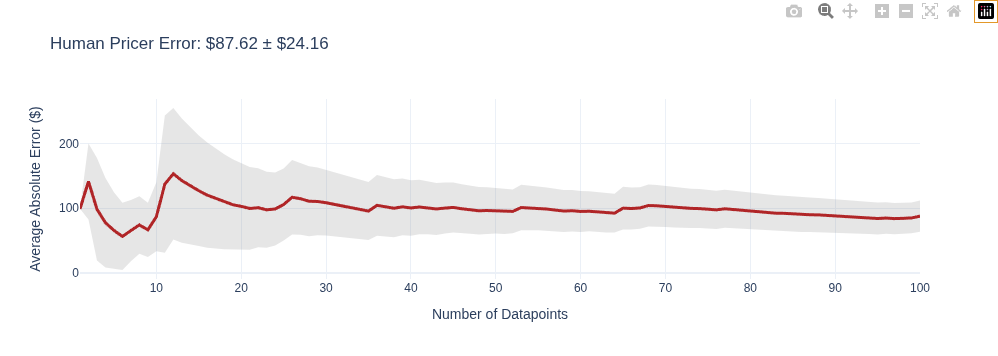

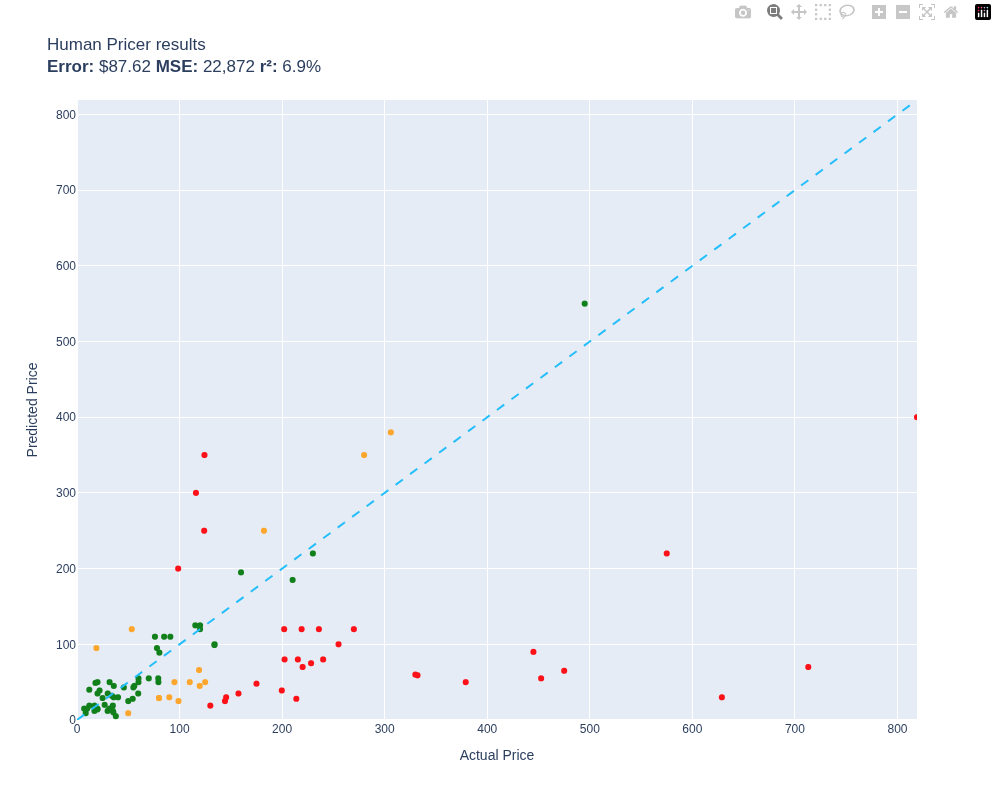

# And now - a vanilla Neural Network

During the remainder of this course we will get deeper into how Neural Networks work, and how to train a neural network.

This is just a sneak preview - let's make our own Neural Network, from scratch, using Pytorch.

Use this to get intuition; it's not important to know all about Neural networks at this point..

In [9]:
# Prepare our documents and prices

y = np.array([float(item.price) for item in train])
documents = [item.summary for item in train]

In [10]:
# Use the HashingVectorizer for a Bag of Words model
# Using binary=True with the CountVectorizer makes "one-hot vectors"

np.random.seed(42)
vectorizer = HashingVectorizer(n_features=5000, stop_words='english', binary=True)
X = vectorizer.fit_transform(documents)

In [11]:
# Define the neural network - here is Pytorch code to create a 8 layer neural network

class NeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super(NeuralNetwork, self).__init__()
        self.layer1 = nn.Linear(input_size, 128)
        self.layer2 = nn.Linear(128, 64)
        self.layer3 = nn.Linear(64, 64)
        self.layer4 = nn.Linear(64, 64)
        self.layer5 = nn.Linear(64, 64)
        self.layer6 = nn.Linear(64, 64)
        self.layer7 = nn.Linear(64, 64)
        self.layer8 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        output1 = self.relu(self.layer1(x))
        output2 = self.relu(self.layer2(output1))
        output3 = self.relu(self.layer3(output2))
        output4 = self.relu(self.layer4(output3))
        output5 = self.relu(self.layer5(output4))
        output6 = self.relu(self.layer6(output5))
        output7 = self.relu(self.layer7(output6))
        output8 = self.layer8(output7)
        return output8

In [12]:
# Convert data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X.toarray())
y_train_tensor = torch.FloatTensor(y).unsqueeze(1)

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_tensor, y_train_tensor, test_size=0.01, random_state=42)

# Create the loader
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Initialize the model
input_size = X_train_tensor.shape[1]
model = NeuralNetwork(input_size)

In [13]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Number of trainable parameters: {trainable_params:,}")

Number of trainable parameters: 669,249


In [14]:
# Define loss function and optimizer

loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# We will do 2 complete runs through the data

EPOCHS = 2

for epoch in range(EPOCHS):
    model.train()
    for batch_X, batch_y in tqdm(train_loader):
        optimizer.zero_grad()

        # The next 4 lines are the 4 stages of training: forward pass, loss calculation, backward pass, optimize
        
        outputs = model(batch_X)
        loss = loss_function(outputs, batch_y)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = loss_function(val_outputs, y_val)

    print(f'Epoch [{epoch+1}/{EPOCHS}], Train Loss: {loss.item():.3f}, Val Loss: {val_loss.item():.3f}')

  0%|          | 0/12375 [00:00<?, ?it/s]

Epoch [1/2], Train Loss: 6914.466, Val Loss: 11706.936


  0%|          | 0/12375 [00:00<?, ?it/s]

Epoch [2/2], Train Loss: 6174.127, Val Loss: 11239.969


In [15]:
def neural_network(item):
    model.eval()
    with torch.no_grad():
        vector = vectorizer.transform([item.summary])
        vector = torch.FloatTensor(vector.toarray())
        result = model(vector)[0].item()
    return max(0, result)

In [16]:
evaluate(neural_network, test)

  0%|          | 0/200 [00:00<?, ?it/s]

$91 $175 $15 $48 $23 $14 $62 $95 $41 $221 $88 $155 $47 $113 $16 $9 $9 $21 $14 $44 $30 $68 $86 $46 $7 $211 $221 $48 $133 $47 $96 $117 $73 $29 $70 $336 $52 $41 $97 $51 $145 $24 $29 $58 $24 $49 $39 $52 $50 $83 $37 $7 $56 $8 $57 $158 $32 $309 $27 $37 $97 $3 $35 $31 $193 $54 $83 $360 $46 $123 $9 $24 $263 $121 $13 $87 $112 $13 $16 $85 $48 $93 $46 $54 $19 $238 $117 $43 $41 $391 $35 $13 $5 $11 $53 $58 $17 $26 $26 $189 $15 $29 $16 $68 $14 $32 $55 $258 $19 $56 $30 $77 $121 $32 $47 $90 $37 $153 $35 $165 $21 $108 $90 $0 $76 $55 $26 $91 $128 $2 $47 $40 $67 $18 $94 $27 $52 $11 $63 $28 $0 $125 $41 $125 $35 $63 $37 $159 $3 $5 $16 $124 $1 $4 $30 $115 $152 $13 $24 $15 $29 $4 $6 $25 $205 $36 $32 $35 $17 $58 $35 $21 $243 $58 $15 $54 $20 $2 $30 $157 $6 $18 $171 $35 $47 $39 $72 $201 $60 $33 $50 $25 $13 $234 $15 $63 $265 $9 $1 $4 

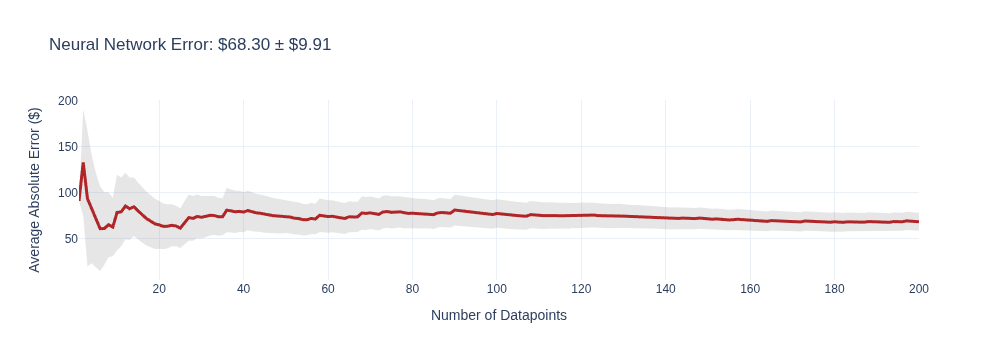

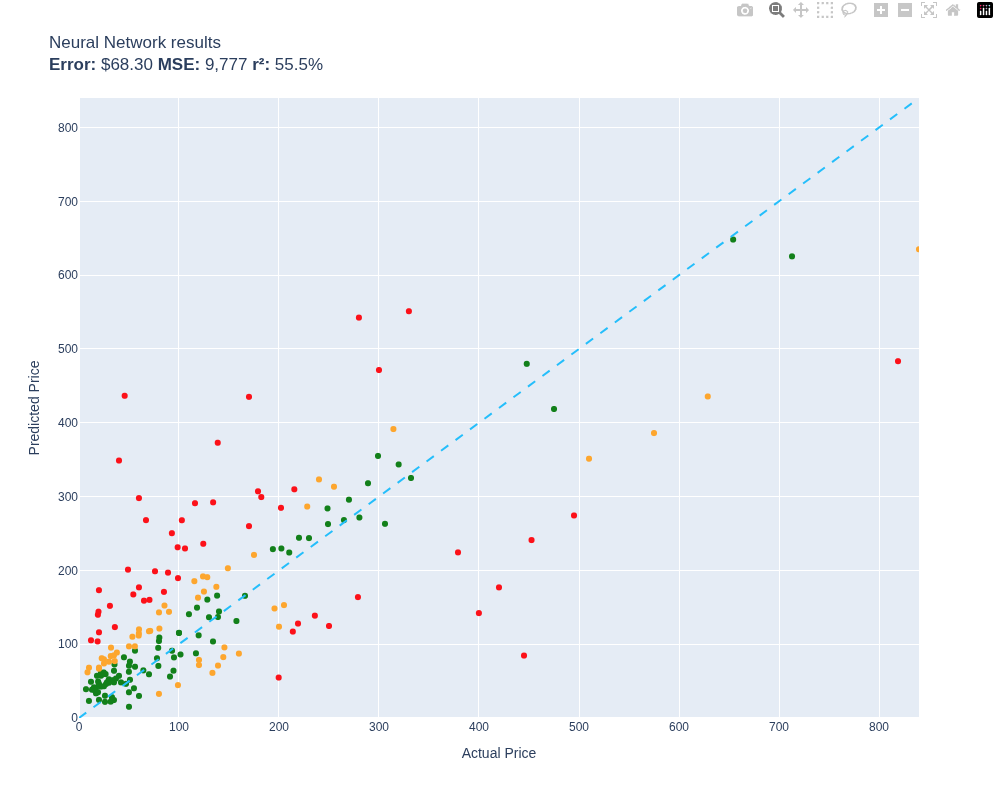

# And now - to the frontier!

Let's see how Frontier models do out of the box; no training, just inference based on their world knowledge.

Tomorrow we will do some training.

In [17]:
def messages_for(item):
    message = f"Estimate the price of this product. Respond with the price, no explanation\n\n{item.summary}"
    return [{"role": "user", "content": message}]

In [18]:
print(test[0].summary)

Title: Excess V2 Distortion/Modulation Pedal  
Category: Music Pedals  
Brand: Old Blood Noise  
Description: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  
Details: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.


In [19]:
messages_for(test[0])

[{'role': 'user',
  'content': 'Estimate the price of this product. Respond with the price, no explanation\n\nTitle: Excess V2 Distortion/Modulation Pedal  \nCategory: Music Pedals  \nBrand: Old Blood Noise  \nDescription: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  \nDetails: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.'}]

In [20]:
# The function for gpt-4.1-nano

def gpt_4__1_nano(item):
    response = completion(model="openai/gpt-4.1-nano", messages=messages_for(item))
    return response.choices[0].message.content

In [21]:
gpt_4__1_nano(test[0])

'$200'

In [22]:
test[0].price

219.0

In [23]:
evaluate(gpt_4__1_nano, test)

  0%|          | 0/200 [00:00<?, ?it/s]

$31 $34 $25 $10 $20 $100 $6 $65 $11 $870 $263 $170 $10 $6 $19 $8 $41 $5 $40 $31 $34 $26 $65 $25 $182 $303 $705 $5 $351 $60 $20 $15 $10 $50 $35 $169 $90 $31 $36 $13 $165 $50 $25 $105 $70 $0 $32 $13 $65 $52 $23 $105 $225 $10 $147 $16 $8 $40 $48 $13 $86 $2 $41 $40 $129 $30 $90 $295 $75 $74 $17 $8 $130 $1 $15 $20 $126 $0 $8 $3 $30 $3 $5 $64 $14 $10 $32 $44 $0 $16 $13 $15 $5 $20 $2 $78 $1 $7 $20 $375 $20 $3 $7 $11 $101 $32 $10 $380 $4 $49 $10 $86 $49 $53 $104 $80 $0 $5 $64 $47 $19 $161 $50 $84 $29 $10 $5 $151 $29 $89 $79 $13 $65 $5 $85 $0 $55 $10 $78 $62 $6 $50 $70 $10 $144 $48 $10 $390 $85 $13 $3 $144 $22 $20 $4 $29 $101 $36 $20 $5 $511 $18 $7 $2 $240 $3 $752 $35 $10 $5 $10 $3 $20 $8 $52 $201 $3 $57 $36 $23 $546 $25 $150 $1 $30 $8 $83 $3 $20 $2 $10 $99 $15 $11 $30 $70 $10 $70 $16 $1 

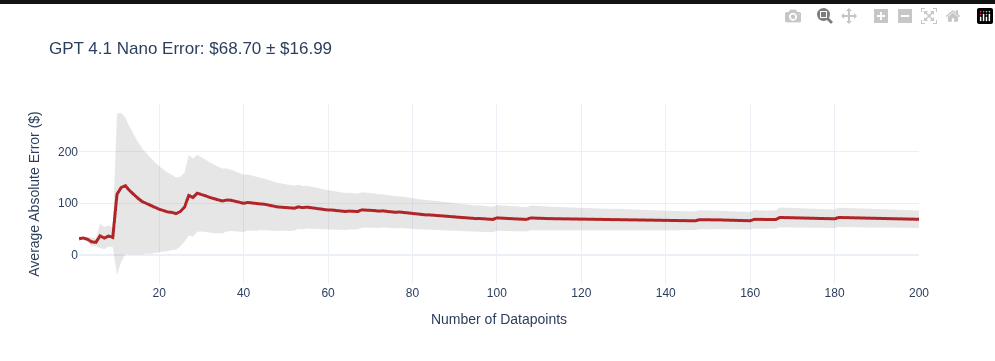

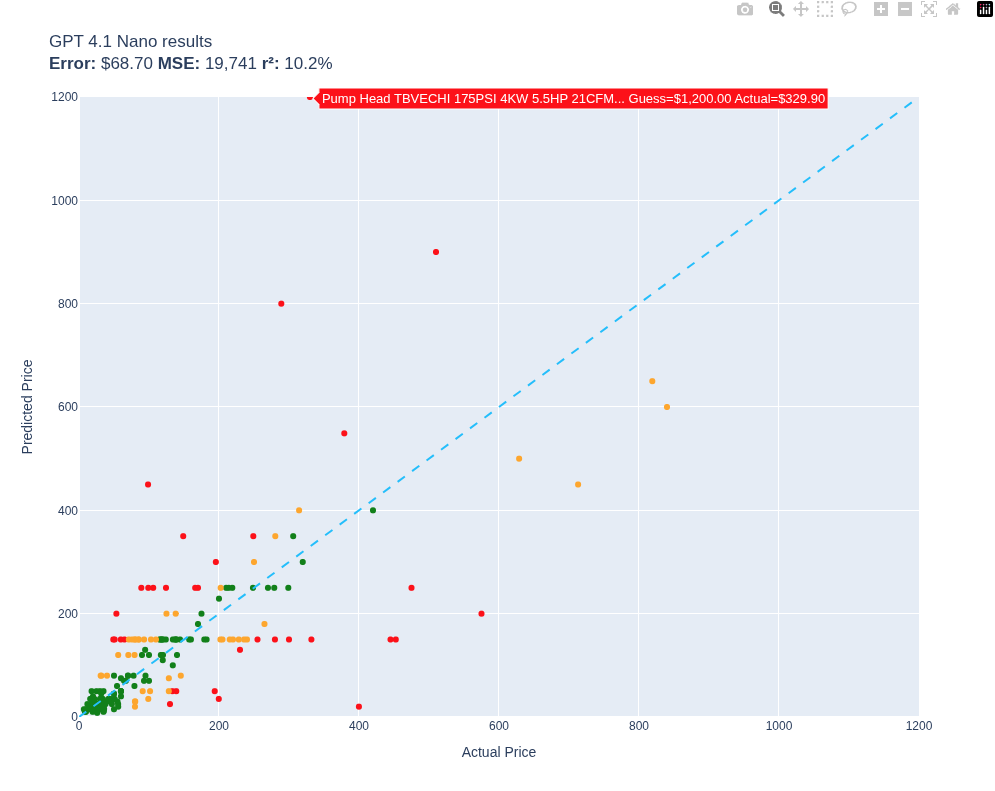

In [24]:
ANTHROPIC_MIN_SECONDS_BETWEEN_REQUESTS = 1.3
ANTHROPIC_MAX_RETRIES = 3
anthropic_lock = threading.Lock()
last_anthropic_request_at = 0.0

def throttled_anthropic_completion(**kwargs):
    global last_anthropic_request_at
    for attempt in range(ANTHROPIC_MAX_RETRIES):
        with anthropic_lock:
            elapsed = time.monotonic() - last_anthropic_request_at
            if elapsed < ANTHROPIC_MIN_SECONDS_BETWEEN_REQUESTS:
                time.sleep(ANTHROPIC_MIN_SECONDS_BETWEEN_REQUESTS - elapsed)
            last_anthropic_request_at = time.monotonic()
        try:
            return completion(**kwargs)
        except RateLimitError:
            if attempt == ANTHROPIC_MAX_RETRIES - 1:
                raise
            time.sleep(20 * (attempt + 1))

def claude_opus_4_5(item):
    response = throttled_anthropic_completion(model="anthropic/claude-opus-4-5", messages=messages_for(item))
    return response.choices[0].message.content

In [25]:
evaluate(claude_opus_4_5, test, workers=1)

  0%|          | 0/200 [00:00<?, ?it/s]

$20 $34 $15 $25 $0 $30 $94 $65 $6 $45 $214 $129 $5 $21 $49 $3 $11 $20 $20 $74 $16 $6 $40 $25 $33 $254 $196 $5 $190 $64 $10 $30 $70 $50 $35 $290 $10 $43 $34 $8 $154 $55 $10 $5 $70 $0 $2 $2 $65 $112 $28 $114 $325 $10 $27 $44 $6 $50 $48 $1 $106 $48 $61 $60 $279 $9 $50 $355 $35 $14 $19 $3 $70 $6 $20 $11 $26 $2 $2 $6 $30 $3 $5 $76 $14 $25 $22 $44 $30 $1 $3 $5 $5 $22 $0 $98 $4 $67 $120 $225 $10 $13 $7 $49 $49 $32 $12 $365 $1 $130 $30 $36 $1 $38 $54 $29 $6 $5 $6 $47 $4 $161 $10 $76 $0 $15 $7 $9 $30 $89 $119 $12 $39 $0 $25 $2 $55 $10 $3 $12 $16 $249 $30 $7 $64 $2 $15 $25 $85 $8 $6 $44 $31 $94 $1 $89 $26 $43 $35 $20 $40 $18 $8 $0 $41 $7 $58 $20 $4 $0 $5 $9 $170 $14 $69 $1 $2 $3 $4 $47 $155 $10 $250 $99 $24 $3 $53 $17 $25 $14 $5 $1 $10 $11 $70 $10 $9 $105 $21 $10 

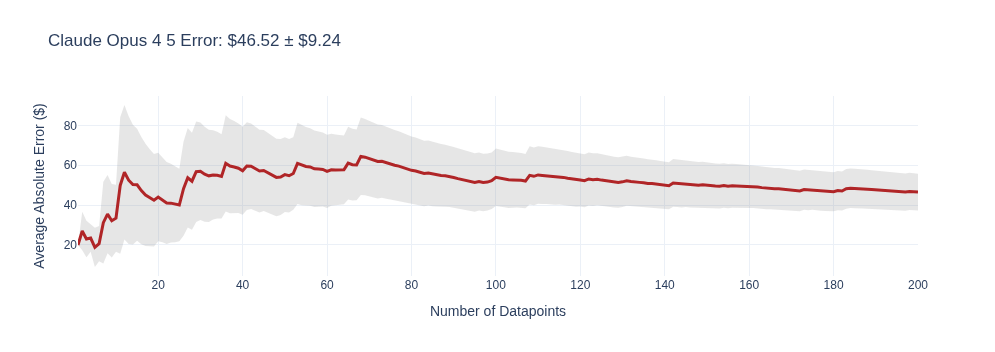

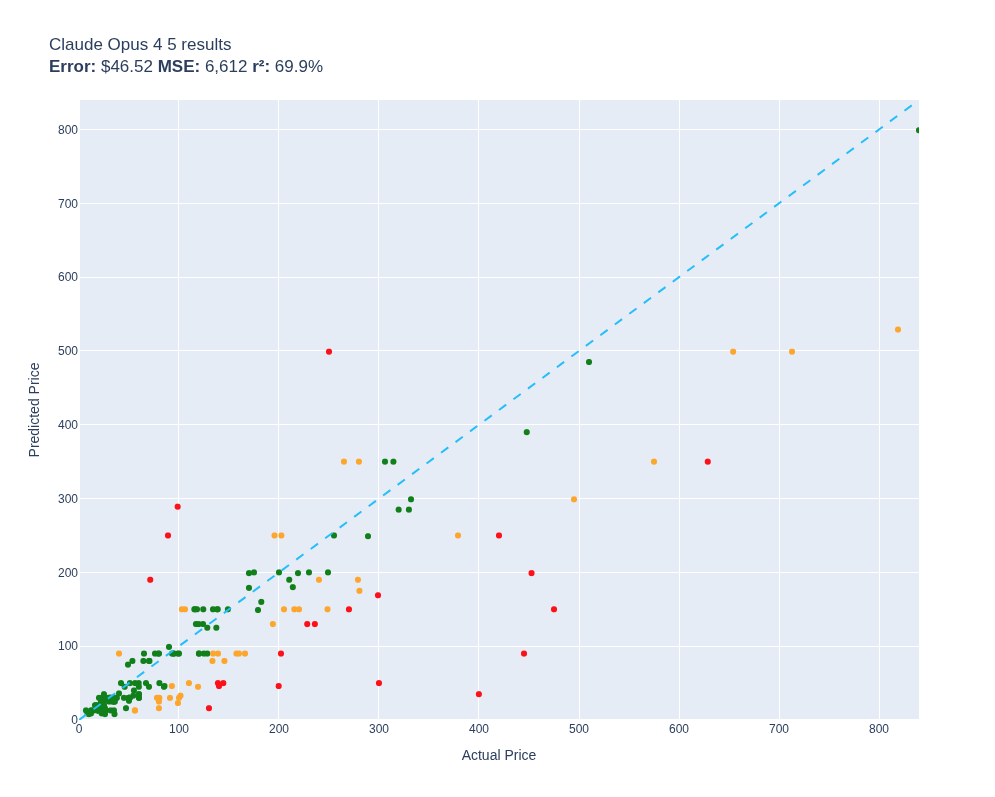

In [26]:
def gemini_3_pro_preview(item):
    response = completion(model="gemini/gemini-3-pro-preview", messages=messages_for(item), reasoning_effort='low')
    return response.choices[0].message.content

In [27]:
evaluate(gemini_3_pro_preview, test, size=50, workers=2)

  0%|          | 0/50 [00:00<?, ?it/s]

$10 $44 $15 $10 $20 $40 $84 $65 $16 $101 $232 $30 $5 $1 $49 $2 $11 $20 $9 $29 $16 $4 $25 $15 $113 $204 $295 $3 $91 $62 $5 $30 $10 $58 $5 $120 $10 $36 $16 $13 $140 $40 $15 $105 $50 $5 $5 $2 $85 $22 

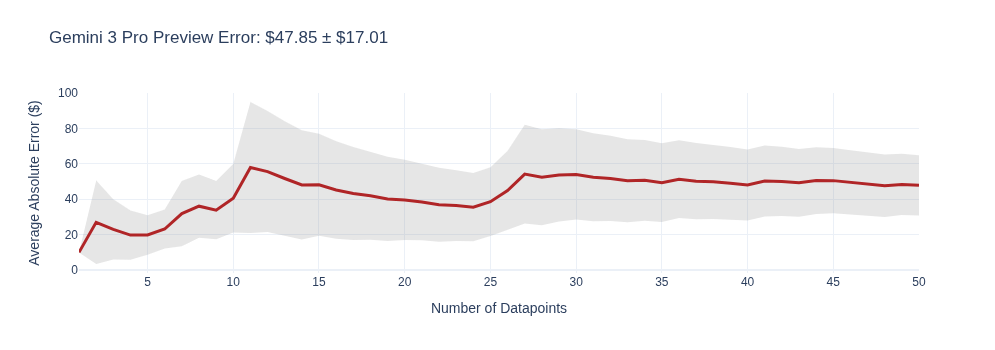

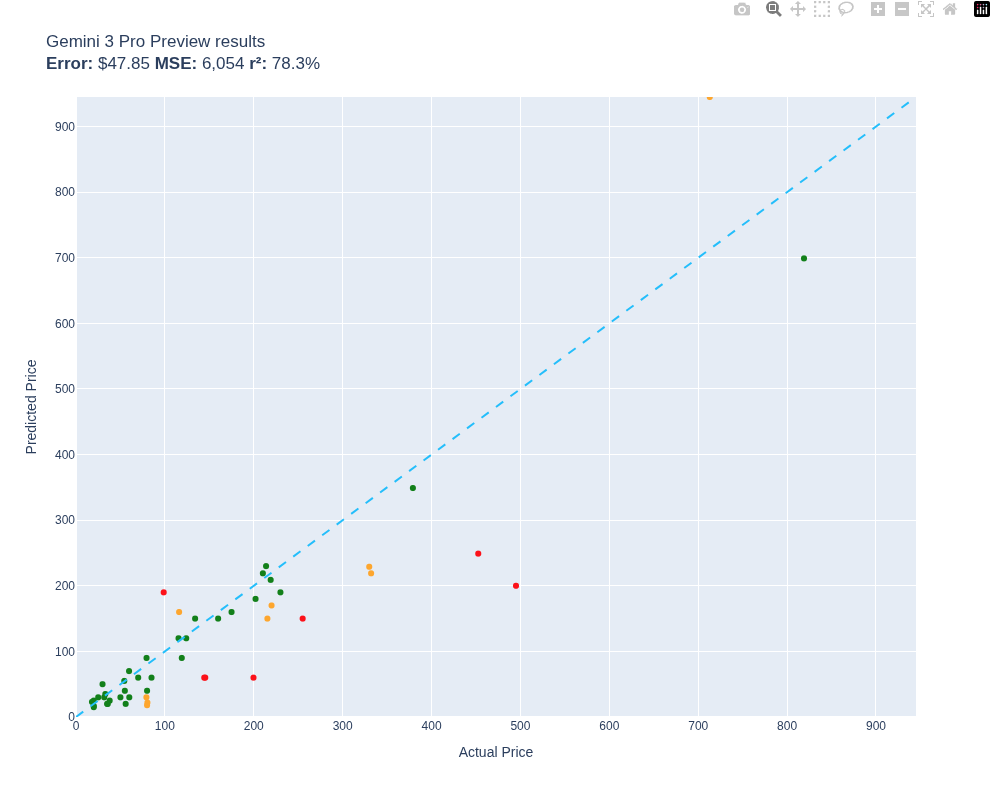

In [38]:
def gemini_2__5_flash_lite(item):
    response = completion(model="gemini/gemini-3.1-flash-lite", messages=messages_for(item))
    return response.choices[0].message.content

In [39]:
evaluate(gemini_2__5_flash_lite, test)


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers



  0%|          | 0/200 [00:00<?, ?it/s]


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/pro

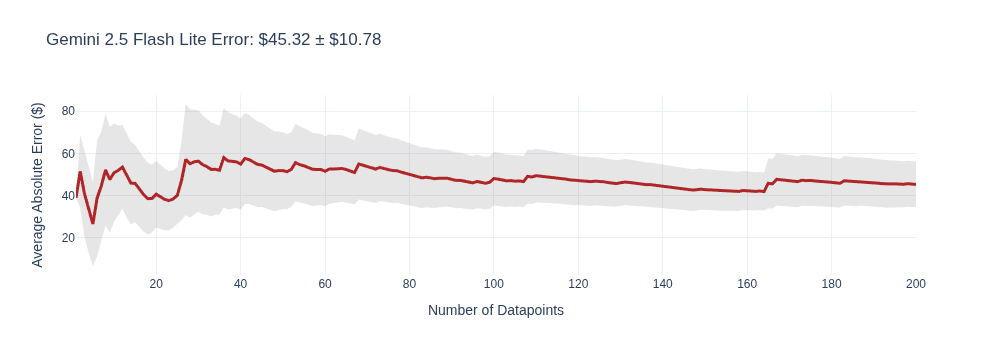

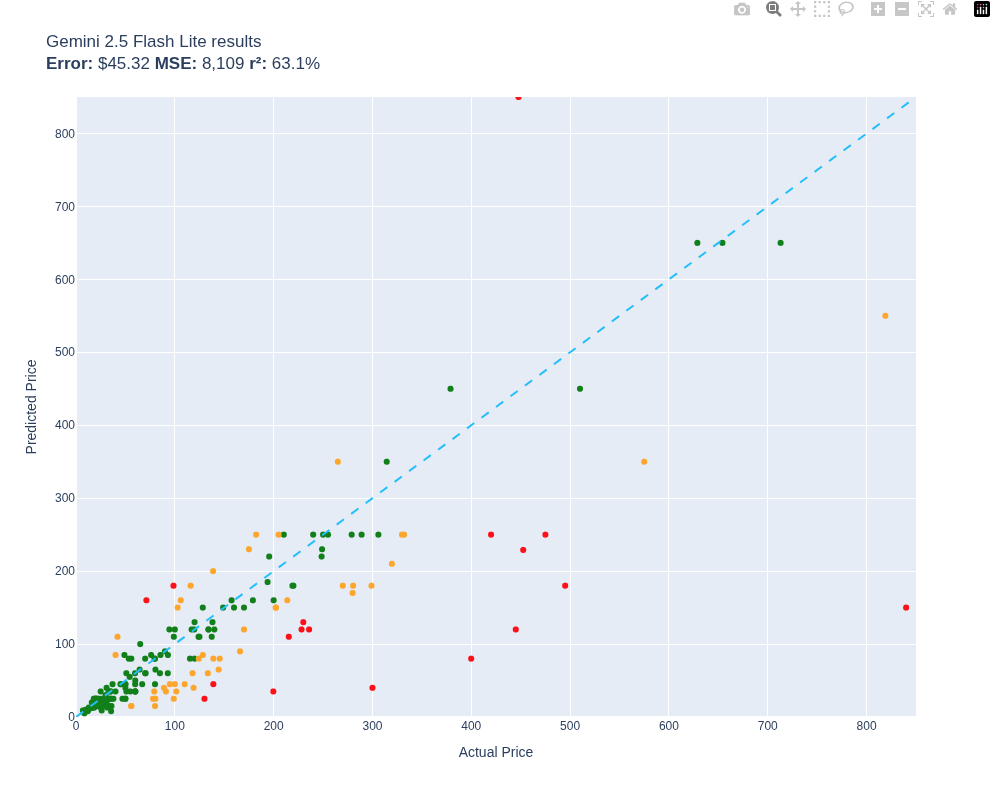

In [42]:
# The function for gpt-5.1

def gpt_5__1(item):
    response = completion(model="gpt-5.1", messages=messages_for(item), reasoning_effort='high', seed=42)
    return response.choices[0].message.content

In [43]:
evaluate(gpt_5__1, test)

  0%|          | 0/200 [00:00<?, ?it/s]

$10 $74 $15 $0 $10 $160 $64 $80 $11 $40 $67 $21 $5 $9 $49 $8 $11 $15 $10 $39 $16 $4 $15 $15 $52 $223 $165 $5 $61 $63 $9 $30 $29 $55 $5 $119 $30 $37 $44 $16 $160 $40 $17 $75 $20 $5 $1 $1 $75 $98 $26 $108 $235 $0 $27 $44 $7 $89 $8 $1 $116 $48 $32 $75 $79 $0 $50 $305 $5 $34 $15 $3 $61 $4 $25 $17 $16 $2 $1 $6 $0 $3 $11 $74 $12 $25 $58 $96 $0 $16 $3 $15 $5 $0 $1 $88 $1 $62 $90 $275 $10 $13 $2 $11 $49 $132 $15 $340 $6 $99 $20 $116 $9 $58 $54 $0 $11 $2 $34 $496 $9 $111 $10 $26 $20 $30 $0 $21 $19 $59 $99 $8 $15 $5 $55 $3 $25 $10 $7 $12 $6 $149 $17 $8 $6 $6 $15 $80 $15 $8 $7 $104 $27 $60 $4 $71 $31 $36 $60 $5 $110 $18 $8 $0 $59 $1 $452 $25 $5 $2 $10 $0 $140 $11 $64 $19 $3 $37 $4 $13 $125 $15 $240 $29 $25 $3 $63 $17 $10 $2 $5 $19 $5 $61 $60 $50 $10 $40 $21 $9 

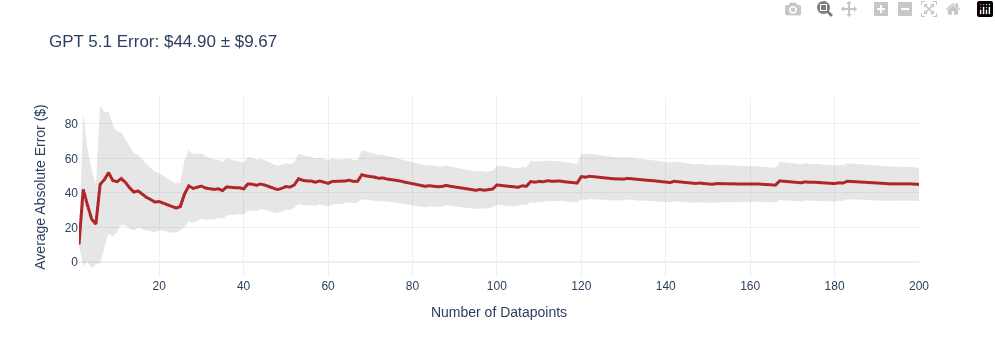

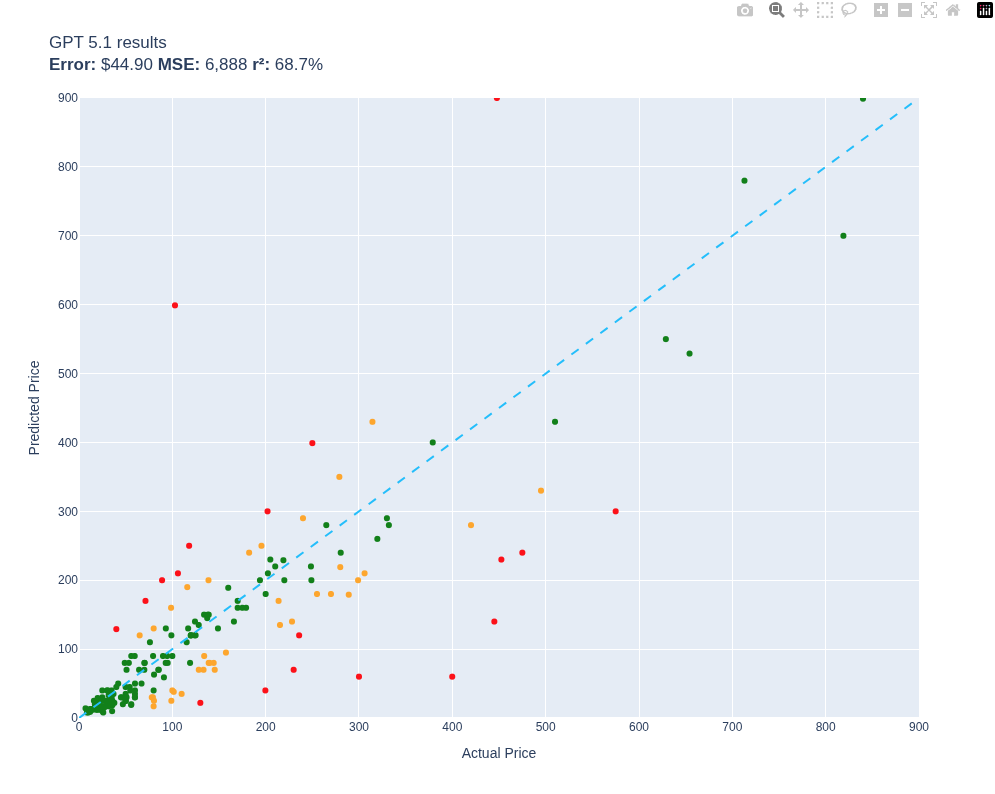

In [ ]:
'''
def grok_4__1_fast(item):
    response = completion(model="xai/grok-4-1-fast-reasoning", messages=messages_for(item), seed=42)
    return response.choices[0].message.content
'''
import os
from litellm import completion

# In Jupyter einmal setzen:
os.environ["XAI_API_KEY"] = "xai-..."  # deinen echten Key einsetzen

def grok_4_1_fast(item):
    response = completion(
        model="xai/grok-4-1-fast-reasoning",
        messages=messages_for(item),
        seed=42,
    )
    return response.choices[0].message.content


In [67]:
evaluate(grok_4__1_fast, test)

  0%|          | 0/200 [00:00<?, ?it/s]

$10 $83 $20 $29 $19 $120 $84 $15 $6 $320 $782 $70 $10 $6 $1 $5 $41 $0 $319 $74 $26 $46 $15 $224 $67 $74 $196 $9 $230 $60 $15 $10 $89 $55 $54 $320 $120 $33 $15 $8 $145 $35 $13 $5 $90 $17 $2 $13 $35 $3 $22 $110 $186 $5 $46 $21 $3 $29 $128 $1 $97 $38 $43 $75 $80 $19 $49 $266 $34 $223 $12 $13 $19 $3 $20 $14 $55 $3 $3 $7 $10 $3 $0 $74 $3 $10 $67 $143 $30 $16 $6 $25 $5 $5 $1 $49 $6 $23 $91 $86 $49 $133 $8 $160 $29 $332 $7 $300 $29 $20 $9 $35 $14 $8 $74 $179 $3 $5 $94 $322 $6 $410 $10 $66 $20 $5 $2 $70 $100 $10 $218 $43 $5 $0 $95 $5 $25 $60 $71 $11 $4 $245 $35 $11 $85 $77 $15 $189 $334 $5 $6 $193 $17 $51 $6 $120 $61 $31 $110 $40 $110 $16 $88 $7 $159 $7 $751 $20 $0 $3 $13 $3 $71 $3 $34 $21 $11 $106 $14 $46 $5 $25 $101 $0 $15 $8 $63 $17 $0 $2 $15 $9 $5 $111 $11 $119 $9 $9 $16 $4 

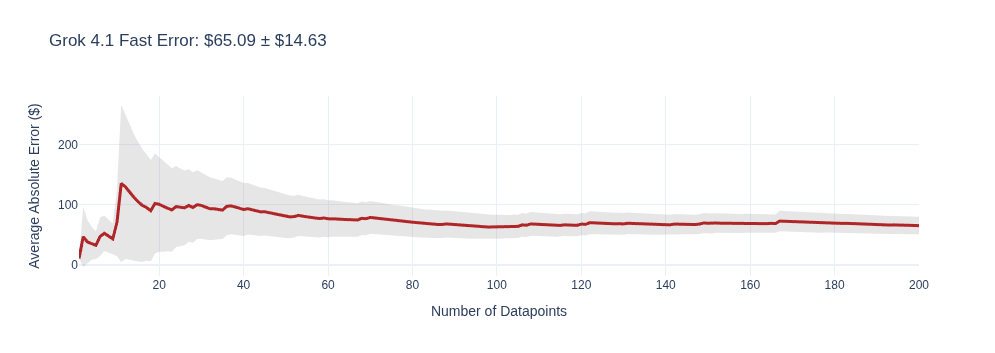

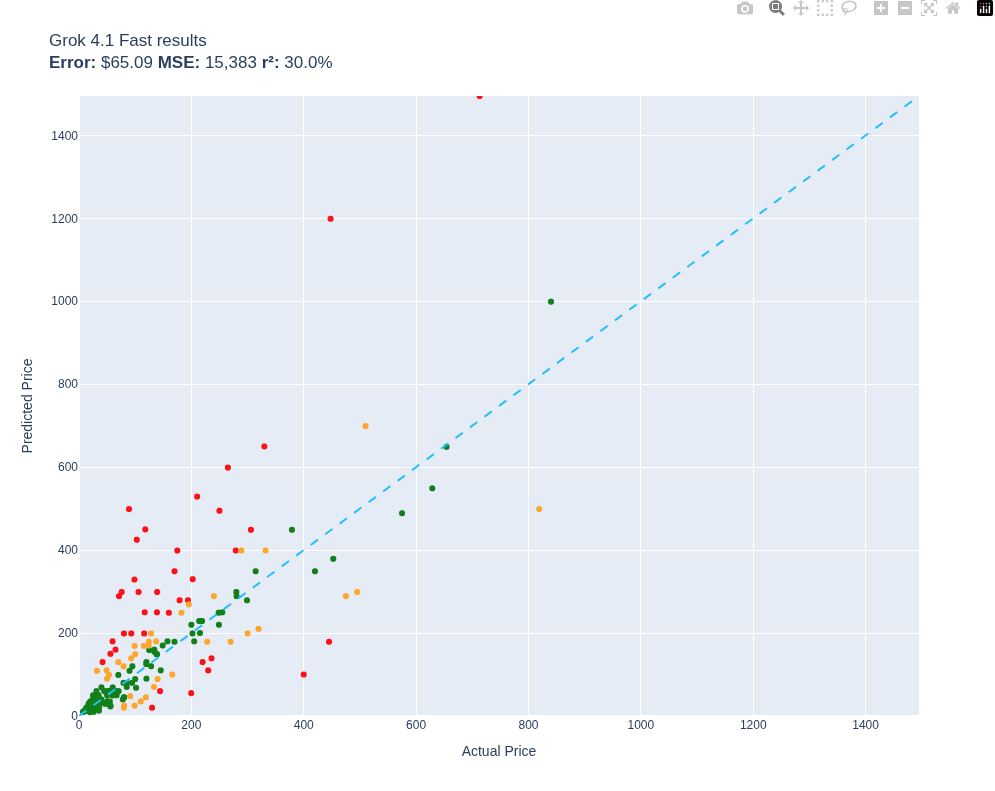